In [1]:
from pyulog import ULog
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use('dark_background')

LOG_PATH = '../data/logs/log_0_2026-6-11-13-47-44.ulg'
ulog = ULog(LOG_PATH)

pos = ulog.get_dataset('vehicle_local_position')
t = pos.data['timestamp']
duration = (t[-1] - t[0]) / 1e6

print(f"Log loaded ✅")
print(f"Duration: {duration:.1f}s ({duration/60:.1f} min)")
print(f"Topics available: {[d.name for d in ulog.data_list]}")

Log loaded ✅
Duration: 73.2s (1.2 min)
Topics available: ['actuator_armed', 'actuator_motors', 'actuator_outputs', 'battery_status', 'config_overrides', 'control_allocator_status', 'cpuload', 'ekf2_timestamps', 'esc_status', 'estimator_aid_src_baro_hgt', 'estimator_aid_src_fake_pos', 'estimator_aid_src_gnss_hgt', 'estimator_aid_src_gnss_pos', 'estimator_aid_src_gnss_vel', 'estimator_aid_src_gravity', 'estimator_aid_src_mag', 'estimator_baro_bias', 'estimator_event_flags', 'estimator_fusion_control', 'estimator_gps_status', 'estimator_innovation_test_ratios', 'estimator_innovation_variances', 'estimator_innovations', 'estimator_sensor_bias', 'estimator_states', 'estimator_status', 'estimator_status_flags', 'event', 'failsafe_flags', 'failure_detector_status', 'home_position', 'hover_thrust_estimate', 'landing_gear', 'logger_status', 'mission_result', 'navigator_mission_item', 'navigator_status', 'position_setpoint_triplet', 'rate_ctrl_status', 'rtl_status', 'rtl_time_estimate', 'sensor_

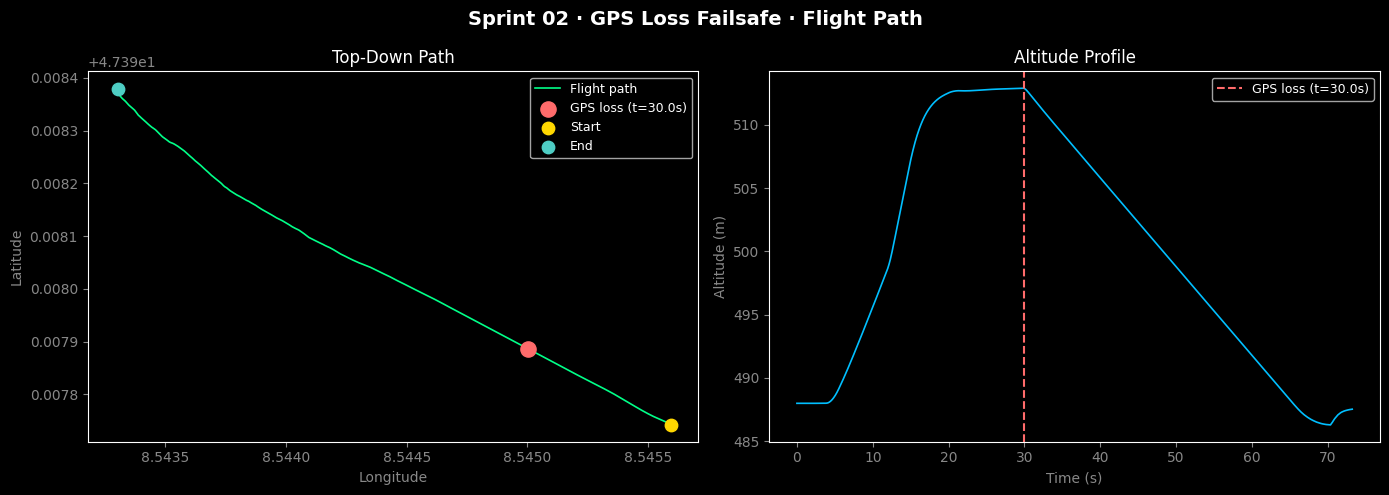

Flight path saved ✅


In [2]:
gps = ulog.get_dataset('vehicle_global_position')
t_gps = (gps.data['timestamp'] - gps.data['timestamp'][0]) / 1e6
lat = gps.data['lat']
lon = gps.data['lon']
alt = gps.data['alt']

GPS_LOSS_T = 30.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sprint 02 · GPS Loss Failsafe · Flight Path',
             color='white', fontsize=14, fontweight='bold')

# Top-down path
ax1 = axes[0]
ax1.plot(lon, lat, color='#00FF88', linewidth=1.2, label='Flight path')
idx_fs = np.argmin(np.abs(t_gps - GPS_LOSS_T))
ax1.scatter(lon[idx_fs], lat[idx_fs], color='#FF6B6B', s=120, zorder=5, label=f'GPS loss (t={GPS_LOSS_T}s)')
ax1.scatter(lon[0], lat[0], color='#FFD700', s=80, zorder=5, label='Start')
ax1.scatter(lon[-1], lat[-1], color='#4ECDC4', s=80, zorder=5, label='End')
ax1.set_xlabel('Longitude', color='#888888')
ax1.set_ylabel('Latitude', color='#888888')
ax1.set_title('Top-Down Path', color='white')
ax1.legend(fontsize=9)
ax1.tick_params(colors='#888888')

# Altitude profile
ax2 = axes[1]
ax2.plot(t_gps, alt, color='#00BFFF', linewidth=1.2)
ax2.axvline(x=GPS_LOSS_T, color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'GPS loss (t={GPS_LOSS_T}s)')
ax2.set_xlabel('Time (s)', color='#888888')
ax2.set_ylabel('Altitude (m)', color='#888888')
ax2.set_title('Altitude Profile', color='white')
ax2.legend(fontsize=9)
ax2.tick_params(colors='#888888')

plt.tight_layout()
plt.savefig('../data/flight_path_failsafe_gps_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Flight path saved ✅")

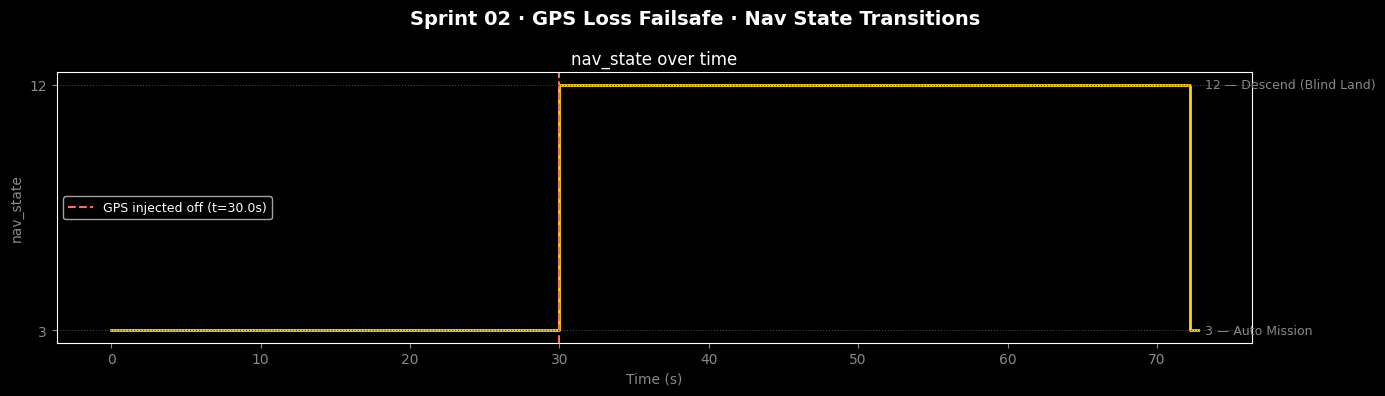

Nav state plot saved ✅


In [3]:
vs = ulog.get_dataset('vehicle_status')
t_vs = (vs.data['timestamp'] - vs.data['timestamp'][0]) / 1e6
nav = vs.data['nav_state']

fs = ulog.get_dataset('failsafe_flags')
t_fs = (fs.data['timestamp'] - fs.data['timestamp'][0]) / 1e6

nav_labels = {3: 'Auto Mission', 12: 'Descend (Blind Land)'}

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Sprint 02 · GPS Loss Failsafe · Nav State Transitions',
             color='white', fontsize=14, fontweight='bold')

ax.step(t_vs, nav, color='#FFD700', linewidth=2, where='post')
ax.axvline(x=GPS_LOSS_T, color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'GPS injected off (t={GPS_LOSS_T}s)')

for state, label in nav_labels.items():
    ax.axhline(y=state, color='#444444', linestyle=':', linewidth=0.8)
    ax.text(t_vs[-1] + 0.5, state, f'{state} — {label}', color='#888888', fontsize=9, va='center')

ax.set_yticks(list(nav_labels.keys()))
ax.set_yticklabels([str(k) for k in nav_labels.keys()], color='#888888')
ax.set_xlabel('Time (s)', color='#888888')
ax.set_ylabel('nav_state', color='#888888')
ax.set_title('nav_state over time', color='white')
ax.tick_params(colors='#888888')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/nav_state_failsafe_gps_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Nav state plot saved ✅")

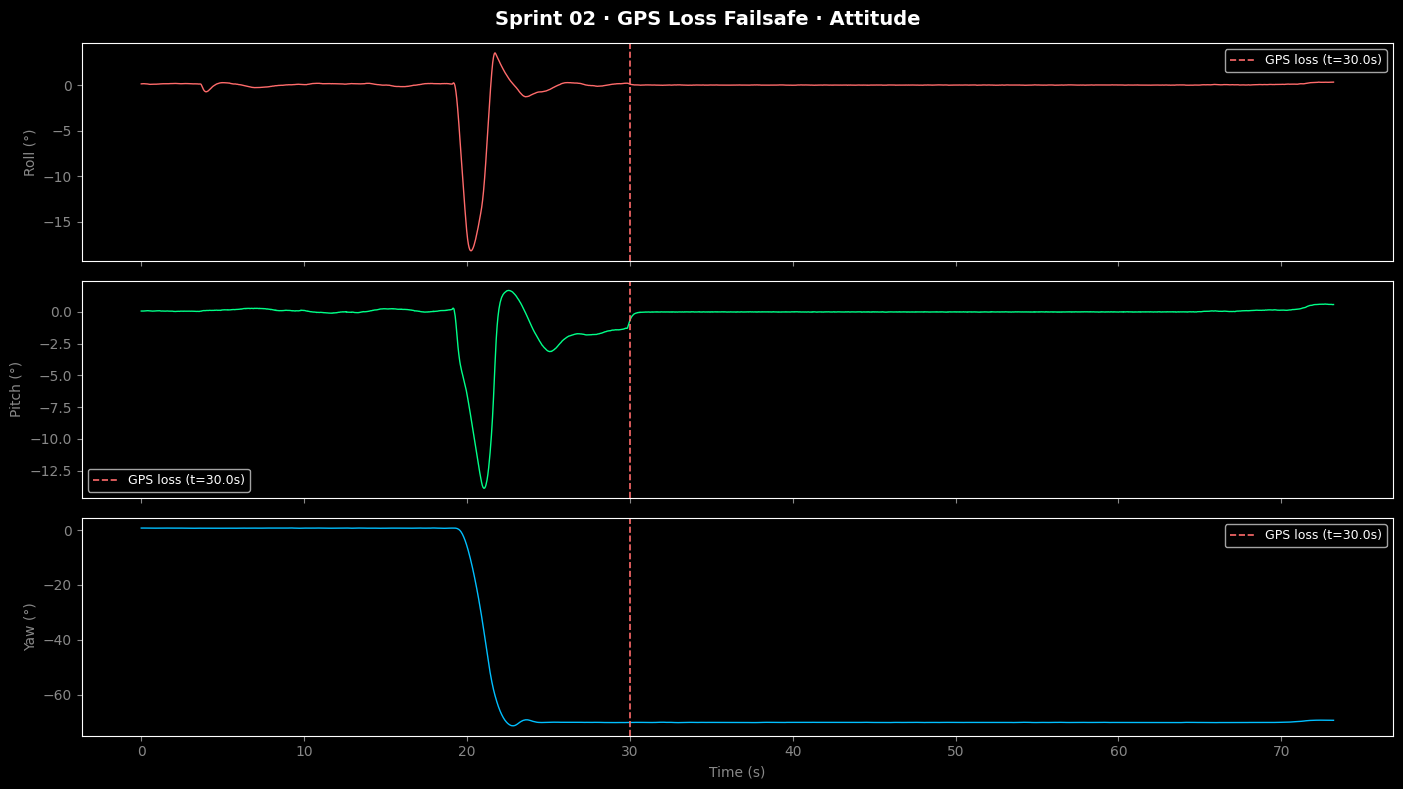

Attitude plot saved ✅


In [4]:
att = ulog.get_dataset('vehicle_attitude')
t_att = (att.data['timestamp'] - att.data['timestamp'][0]) / 1e6
q0, q1, q2, q3 = att.data['q[0]'], att.data['q[1]'], att.data['q[2]'], att.data['q[3]']

roll  = np.degrees(np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1**2 + q2**2)))
pitch = np.degrees(np.arcsin(np.clip(2*(q0*q2 - q3*q1), -1, 1)))
yaw   = np.degrees(np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2**2 + q3**2)))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Sprint 02 · GPS Loss Failsafe · Attitude',
             color='white', fontsize=14, fontweight='bold')

for ax, data, label, color in zip(axes,
                                   [roll, pitch, yaw],
                                   ['Roll (°)', 'Pitch (°)', 'Yaw (°)'],
                                   ['#FF6B6B', '#00FF88', '#00BFFF']):
    ax.plot(t_att, data, color=color, linewidth=1.0)
    ax.axvline(x=GPS_LOSS_T, color='#FF6B6B', linestyle='--', linewidth=1.2, label=f'GPS loss (t={GPS_LOSS_T}s)')
    ax.set_ylabel(label, color='#888888')
    ax.tick_params(colors='#888888')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Time (s)', color='#888888')
plt.tight_layout()
plt.savefig('../data/attitude_failsafe_gps_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attitude plot saved ✅")

In [5]:
# Nav state timestamps
nav_changes = []
prev = None
for t_, n in zip(t_vs, nav):
    if n != prev:
        nav_changes.append((t_, int(n)))
        prev = n

gps_loss_t   = GPS_LOSS_T
failsafe_t   = next(t for t, n in nav_changes if n == 12)
recovery_t   = next(t for t, n in nav_changes if n == 3 and t > failsafe_t)

print("=" * 55)
print("  SPRINT 02 · GPS LOSS FAILSAFE — MISSION SUMMARY")
print("=" * 55)
print(f"  Log file     : log_0_2026-6-11-13-47-44.ulg")
print(f"  Duration     : {duration:.1f}s ({duration/60:.1f} min)")
print(f"  GPS injected : t={gps_loss_t:.1f}s  (failure gps off)")
print(f"  Failsafe     : t={failsafe_t:.1f}s  nav_state=12 (Blind Land)")
print(f"  Landed       : t={recovery_t:.1f}s")
print(f"  Reaction time: {failsafe_t - gps_loss_t:.1f}s")
print("=" * 55)
print("  Failsafe type : No valid position estimate → Descend")
print("  Injection cmd : failure gps off (PX4 SITL CLI)")
print("  EKF behavior  : Switched to fake_pos / dead reckoning")
print("  Outcome       : Controlled descent + landing ✅")
print("=" * 55)

  SPRINT 02 · GPS LOSS FAILSAFE — MISSION SUMMARY
  Log file     : log_0_2026-6-11-13-47-44.ulg
  Duration     : 73.2s (1.2 min)
  GPS injected : t=30.0s  (failure gps off)
  Failsafe     : t=30.0s  nav_state=12 (Blind Land)
  Landed       : t=72.2s
  Reaction time: -0.0s
  Failsafe type : No valid position estimate → Descend
  Injection cmd : failure gps off (PX4 SITL CLI)
  EKF behavior  : Switched to fake_pos / dead reckoning
  Outcome       : Controlled descent + landing ✅
